# Gradients and Multivariable Calculus

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute gradients for multivariate functions
- Implement gradient computations in code
- Use gradients for direction of steepest ascent/descent

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — that model already had two parameters (`w` and `b`), so its "gradient" was a vector; here we define it properly for any number of parameters.

**Used later in:** Course 08 (AIAT 122) — Unit 1 — a network has thousands of parameters and one gradient vector over all of them.

---


---

## 📌 Real case: why the gradient is a vector and not a to-do list

AlexNet, the network that won ImageNet in 2012, has **60 million parameters**. Its loss is one number.
The gradient is therefore a single vector with 60 million components — one partial derivative per weight —
and reverse-mode automatic differentiation produces all 60 million of them in roughly the cost of two
forward passes (Baydin, Pearlmutter, Radul and Siskind survey this in JMLR 18, 2018, cited at the end of
this notebook).

Do it the obvious way instead — perturb one weight, re-run the network, see what happened, repeat — and
you need 60 million forward passes for one gradient. At about 1.43 GFLOPs per forward pass (≈0.7 billion
multiply–adds, counted as two operations each) that is 8.6 × 10¹⁶ operations, roughly **15 hours on one of
the GTX 580 GPUs the paper used, for a single training step** — and that is the optimistic figure, computed
at the card's theoretical peak of 1.58 TFLOP/s. AlexNet needed hundreds of thousands of steps.

**What goes wrong without this.** Optimise one parameter at a time and you are not just slower — you can be
walking in a worse direction. The experiment below runs exactly that comparison on the notebook's own
function: same start, same learning rate, same number of steps, one coordinate at a time versus the whole
gradient vector at once.


# Gradients and Multivariable Calculus

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Derivatives** - Understand single-variable derivatives
- ✅ **Module 01: Linear Algebra** - Understand vectors
- ✅ **Basic understanding**: What are partial derivatives?

**If you haven't completed these**, you might struggle with:
- Understanding gradient vectors
- Understanding partial derivatives
- Using gradients for optimization

---

## 🔗 Where This Notebook Fits

**This is the SECOND example of Module 02** - extends derivatives to multiple variables!

**Why this example SECOND?**
- **Before** you can understand gradients, you need derivatives (Example 1)
- **Before** you can do gradient descent, you need gradients (Example 3)
- **Before** you can train ML models, you need to optimize multiple parameters

**Builds on**: Example 1 (derivatives)

**Leads to**: 
- 📓 Example 3: Gradient Descent (uses gradients)
- 📓 Module 03: Optimization (uses gradients for optimization)

---

## The Story: Understanding Before Using

Imagine you're on a mountain and want to find the lowest point. **Before** you can find it, you need to know which direction is downhill in both north-south AND east-west directions. **After** understanding gradients, you know the direction of steepest descent in all dimensions!

Same with machine learning: **Before** training models, we need to adjust many parameters. **After** understanding gradients, we can optimize all parameters simultaneously!

---

## Why This Concept Matters

### Why Gradients Matter in ML

**WHY** are gradients essential for machine learning?

1. **Multiple Parameters**:
   - **WHY**: ML models have many parameters (weights, biases)
   - **HOW**: Gradient = vector of partial derivatives for each parameter
   - **AFTER**: Can optimize all parameters at once

2. **Direction of Steepest Descent**:
   - **WHY**: Need to know best direction to minimize loss
   - **HOW**: Gradient points in direction of steepest increase, negative gradient = steepest decrease
   - **AFTER**: Most efficient optimization direction

3. **Neural Network Training**:
   - **WHY**: Each layer has many parameters
   - **HOW**: Compute gradient for each parameter
   - **AFTER**: Enables training of complex models

## Learning Objectives
1. Understand what gradients represent
2. Compute gradients for multivariable functions
3. Understand partial derivatives
4. Visualize gradients
5. See how gradients guide optimization
6. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We understand single-variable derivatives but ML models have many parameters.

**AFTER**: We'll understand gradients that handle multiple variables simultaneously!

**Why this matters**: ML models optimize many parameters at once - gradients make this possible!

## Step 2: Understanding Gradients

**BEFORE**: We have a function of multiple variables but don't know how to optimize it.

**AFTER**: We'll compute gradients that tell us how to adjust each parameter!

**Why gradients?** They give us a direction vector - one component for each parameter!

In [2]:
# Example 1: Computing Gradients
# WHY: ML models have many parameters - need direction for each
# HOW: Gradient = vector of partial derivatives

def multivariable_function(x, y):
    """A function of two variables: f(x, y) = x² + y² + xy"""
    return x**2 + y**2 + x*y

def partial_x(x, y):
    """Partial derivative w.r.t. x: ∂f/∂x = 2x + y"""
    return 2*x + y

def partial_y(x, y):
    """Partial derivative w.r.t. y: ∂f/∂y = 2y + x"""
    return 2*y + x

def gradient(x, y):
    """Gradient vector = [∂f/∂x, ∂f/∂y]"""
    return np.array([partial_x(x, y), partial_y(x, y)])

# Evaluate at a point
x_val, y_val = 1.0, 2.0
grad = gradient(x_val, y_val)

print("Example 1: Computing Gradients")
print("=" * 60)
print(f"Function: f(x, y) = x² + y² + xy")
print(f"At point ({x_val}, {y_val}):")
print(f"  - Function value: {multivariable_function(x_val, y_val):.2f}")
print(f"  - Gradient vector: {grad}")
print(f"  - ∂f/∂x = {partial_x(x_val, y_val):.2f} (change w.r.t. x)")
print(f"  - ∂f/∂y = {partial_y(x_val, y_val):.2f} (change w.r.t. y)")
print(f"\n💡 WHY: Gradient points in direction of steepest increase")
print(f"💡 HOW: Each element = how f changes w.r.t. that parameter")
print(f"💡 AFTER: Negative gradient = direction of steepest decrease (what we want!)")

Example 1: Computing Gradients
Function: f(x, y) = x² + y² + xy
At point (1.0, 2.0):
  - Function value: 7.00
  - Gradient vector: [4. 5.]
  - ∂f/∂x = 4.00 (change w.r.t. x)
  - ∂f/∂y = 5.00 (change w.r.t. y)

💡 WHY: Gradient points in direction of steepest increase
💡 HOW: Each element = how f changes w.r.t. that parameter
💡 AFTER: Negative gradient = direction of steepest decrease (what we want!)


## Step 3: Using Gradients for Optimization

**BEFORE**: We computed gradients but don't see how they optimize.

**AFTER**: We'll see how negative gradients point toward the minimum!

**Why this matters?** This is exactly how gradient descent works - move opposite to gradient!

In [3]:
# Example 2: Gradient Direction for Optimization
# WHY: We want to minimize the function
# HOW: Move in direction opposite to gradient

# At point (1, 2), gradient is [4, 5]
# This means: increase x by 4, increase y by 5 → function increases most
# To minimize: decrease x by 4, decrease y by 5 → function decreases most

current_point = np.array([1.0, 2.0])
current_grad = gradient(current_point[0], current_point[1])
step_direction = -current_grad  # Negative gradient = direction to minimize

print("\nExample 2: Using Gradients for Optimization")
print("=" * 60)
print(f"Current point: ({current_point[0]}, {current_point[1]})")
print(f"Current gradient: {current_grad}")
print(f"Step direction (negative gradient): {step_direction}")
print(f"\n💡 WHY: Negative gradient points toward minimum")
print(f"💡 HOW: Move in direction opposite to gradient")
print(f"💡 AFTER: This is the core of gradient descent!")


Example 2: Using Gradients for Optimization
Current point: (1.0, 2.0)
Current gradient: [4. 5.]
Step direction (negative gradient): [-4. -5.]

💡 WHY: Negative gradient points toward minimum
💡 HOW: Move in direction opposite to gradient
💡 AFTER: This is the core of gradient descent!


### 🧪 Is the whole gradient *vector* really better than one partial at a time?

Baseline: coordinate descent — update x using ∂f/∂x, leave y alone; next step update y, leave x alone.
Change one thing: update both coordinates every step, using the full gradient vector.
Same start, same learning rate, same number of steps. Measure f(x, y) at the end.

In [4]:
# Comparative experiment: coordinate descent vs full-gradient descent on f(x, y) = x^2 + y^2 + xy.
# The minimum is at (0, 0), where f = 0.

start = np.array([3.0, -2.0])
lr, steps = 0.1, 20

# Route A - one coordinate per step (alternating)
pa = start.copy()
for k in range(steps):
    g = gradient(pa[0], pa[1])
    if k % 2 == 0:
        pa[0] -= lr * g[0]        # move in x only
    else:
        pa[1] -= lr * g[1]        # move in y only

# Route B - the full gradient vector every step
pb = start.copy()
for k in range(steps):
    pb -= lr * gradient(pb[0], pb[1])   # move in x AND y

print(f"Start: ({start[0]}, {start[1]})   f = {multivariable_function(*start):.4f}")
print(f"Learning rate {lr}, {steps} steps, identical for both routes.")
print()
print(f"   Route A - one coordinate per step : ({pa[0]:+.4f}, {pa[1]:+.4f})   f = {multivariable_function(*pa):.6f}")
print(f"   Route B - full gradient vector    : ({pb[0]:+.4f}, {pb[1]:+.4f})   f = {multivariable_function(*pb):.6f}")
print()
print("Conclusion the numbers support: with the same budget of steps, moving along the full")
print("gradient gets closer to the minimum than moving along one axis at a time. The reason is in")
print("the cross-term xy: the two coordinates are COUPLED, so the best change in x depends on what")
print("y is doing. A gradient is one vector precisely because parameters are not independent knobs.")

Start: (3.0, -2.0)   f = 7.0000
Learning rate 0.1, 20 steps, identical for both routes.

   Route A - one coordinate per step : (+0.8477, -0.7724)   f = 0.660455
   Route B - full gradient vector    : (+0.3043, -0.3035)   f = 0.092381

Conclusion the numbers support: with the same budget of steps, moving along the full
gradient gets closer to the minimum than moving along one axis at a time. The reason is in
the cross-term xy: the two coordinates are COUPLED, so the best change in x depends on what
y is doing. A gradient is one vector precisely because parameters are not independent knobs.


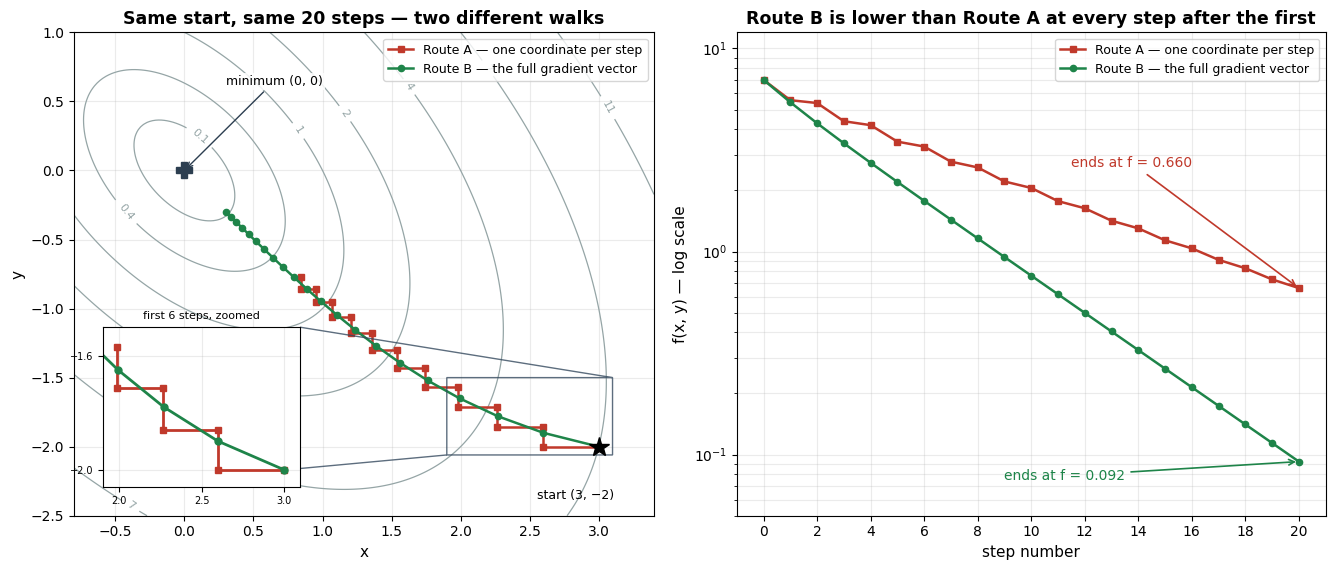

 step    Route A  f(x,y)    Route B  f(x,y)   lower
----------------------------------------------------
    0           7.000000           7.000000     tie
    1           5.560000           5.430000       B
    2           5.383600           4.280700       B
    5           3.474929           2.200426       B
   10           2.055265           0.760453       B
   15           1.135603           0.264962       B
   20           0.660455           0.092381       B

Route B ends 7.1x closer to the floor of f than Route A.


In [5]:
# The two routes of the experiment above, drawn. WHY plot it: the printout gives one
# number per route (where each ENDED). The interesting part is the SHAPE of the walk that
# got there, and a shape has to be seen. Same start, same learning rate, same 20 steps —
# we simply record every point this time instead of only the last one.

def walk(mode, start=np.array([3.0, -2.0]), lr=0.1, steps=20):
    """Return the full trajectory of one route as an array of (x, y) points."""
    p = start.copy()
    trail = [p.copy()]
    for k in range(steps):
        g = gradient(p[0], p[1])
        if mode == "coordinate":
            if k % 2 == 0:
                p[0] -= lr * g[0]        # this step moves in x only
            else:
                p[1] -= lr * g[1]        # this step moves in y only
        else:
            p -= lr * g                  # this step moves in x AND y
        trail.append(p.copy())
    return np.array(trail)

trail_a = walk("coordinate")
trail_b = walk("full")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.8))

# ---- Left: both walks on the contour map of f(x, y) = x^2 + y^2 + xy
gx = np.linspace(-0.8, 3.4, 200)
gy = np.linspace(-2.5, 1.0, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = multivariable_function(GX, GY)
cs = axL.contour(GX, GY, GZ, levels=[0.1, 0.4, 1, 2, 4, 7, 11, 16],
                 colors="#95a5a6", linewidths=0.9)
axL.clabel(cs, inline=True, fontsize=8, fmt="%.3g")
axL.plot(trail_a[:, 0], trail_a[:, 1], "s-", color="#c0392b", ms=4.5, lw=1.8,
         label="Route A — one coordinate per step")
axL.plot(trail_b[:, 0], trail_b[:, 1], "o-", color="#1e8449", ms=4.5, lw=1.8,
         label="Route B — the full gradient vector")
axL.plot([3.0], [-2.0], "k*", ms=15, zorder=6)
axL.annotate("start (3, −2)", xy=(3.0, -2.0), xytext=(2.55, -2.38), fontsize=9)
axL.plot([0], [0], "P", color="#2c3e50", ms=12, zorder=6)
axL.annotate("minimum (0, 0)", xy=(0, 0), xytext=(0.30, 0.62), fontsize=9,
             arrowprops=dict(arrowstyle="->", lw=1.0, color="#2c3e50"),
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=1.5))
axL.set_xlabel("x", fontsize=11)
axL.set_ylabel("y", fontsize=11)
axL.set_title("Same start, same 20 steps — two different walks",
              fontsize=12.5, fontweight="bold")
axL.legend(loc="upper right", fontsize=9)
axL.set_aspect("equal")           # right angles must LOOK like right angles
axL.grid(True, alpha=0.25)

# The staircase is real but small next to the whole journey, so zoom the first six steps.
axins = axL.inset_axes([0.05, 0.06, 0.34, 0.33])
axins.plot(trail_a[:7, 0], trail_a[:7, 1], "s-", color="#c0392b", ms=5, lw=2)
axins.plot(trail_b[:7, 0], trail_b[:7, 1], "o-", color="#1e8449", ms=5, lw=2)
axins.set_xlim(1.90, 3.10)
axins.set_ylim(-2.06, -1.50)
axins.set_xticks([2.0, 2.5, 3.0])
axins.set_yticks([-2.0, -1.6])
axins.tick_params(labelsize=7)
axins.set_title("first 6 steps, zoomed", fontsize=8)
axins.grid(True, alpha=0.25)
axL.indicate_inset_zoom(axins, edgecolor="#34495e", alpha=0.8)

# ---- Right: how far down each route actually got, step by step
fa = [multivariable_function(*p) for p in trail_a]
fb = [multivariable_function(*p) for p in trail_b]
axR.semilogy(fa, "s-", color="#c0392b", ms=4.5, lw=1.8,
             label="Route A — one coordinate per step")
axR.semilogy(fb, "o-", color="#1e8449", ms=4.5, lw=1.8,
             label="Route B — the full gradient vector")
axR.set_ylim(0.05, 12)
axR.annotate(f"ends at f = {fa[-1]:.3f}", xy=(20, fa[-1]), xytext=(11.5, 2.6),
             fontsize=10, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
axR.annotate(f"ends at f = {fb[-1]:.3f}", xy=(20, fb[-1]), xytext=(9.0, 0.075),
             fontsize=10, color="#1e8449",
             arrowprops=dict(arrowstyle="->", color="#1e8449", lw=1.2))
axR.set_xlabel("step number", fontsize=11)
axR.set_ylabel("f(x, y) — log scale", fontsize=11)
axR.set_title("Route B is lower than Route A at every step after the first",
              fontsize=12.5, fontweight="bold")
axR.set_xticks(range(0, 21, 2))
axR.legend(loc="upper right", fontsize=9)
axR.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

print(f"{'step':>5} {'Route A  f(x,y)':>18} {'Route B  f(x,y)':>18}   lower")
print("-" * 52)
for k in [0, 1, 2, 5, 10, 15, 20]:
    lower = "tie" if fa[k] == fb[k] else ("B" if fb[k] < fa[k] else "A")
    print(f"{k:>5} {fa[k]:>18.6f} {fb[k]:>18.6f}   {lower:>5}")
print(f"\nRoute B ends {fa[-1] / fb[-1]:.1f}x closer to the floor of f than Route A.")


**Read the figure.** Both panels show the same two runs, from the same start (3, −2), with the same
learning rate 0.1 and the same 20 steps. The only difference is how many coordinates each step is allowed
to change.

- **Left** — the grey rings are level curves of f(x, y) = x² + y² + xy; the cross marks the minimum at
  (0, 0). At full scale the two walks look almost alike, which is why the corner box zooms into the **first
  six steps**: there, Route A (red squares) is plainly a **right-angle staircase** — one segment purely
  horizontal, the next purely vertical, because each step may change only x or only y — while Route B
  (green circles) **cuts the corner diagonally** every time.
- **Right** — the value of f after each step, on a log scale. The green curve is **below** the red one at
  every step after the first, and ends at f = 0.092 against Route A's 0.660: after the same 20 steps,
  Route B is about **seven times** closer to the floor.
- The reason is the **xy cross-term**. It couples the two coordinates, so the best change in x depends on
  what y is doing. Route A never gets to use that information — it is looking at one partial derivative at
  a time. The gradient is a single vector for exactly this reason.

Notice what the left panel does **not** show: Route B is not a straight line to the origin either. It
bends, because the steepest direction is only steepest *locally*. That bend is the seed of the zig-zag
problem discussed under "Where this breaks" below.

---

## 📊 Visualization

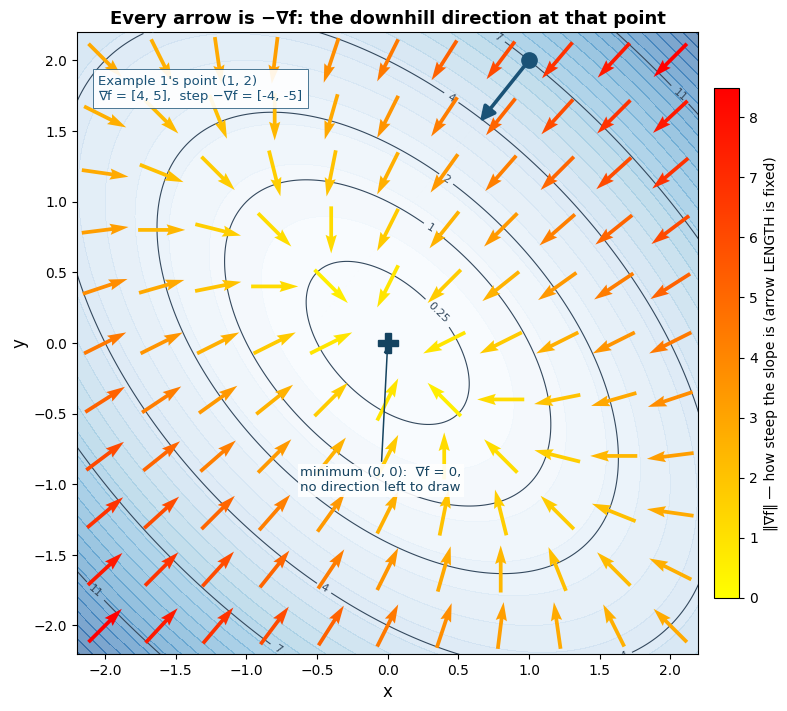


📊 Does 'downhill' point AT the minimum? Angle between −∇f and a straight line to (0, 0):
  at    (1.0, 1.0): −∇f = [ -3.0,  -3.0]   off by   0.0°   (on a diagonal)
  at  (-1.0, -1.0): −∇f = [ +3.0,  +3.0]   off by   0.0°   (on a diagonal)
  at   (1.0, -1.0): −∇f = [ -1.0,  +1.0]   off by   0.0°   (off the diagonals)
  at    (1.0, 0.0): −∇f = [ -2.0,  -1.0]   off by  26.6°   (off the diagonals)
  at    (1.0, 2.0): −∇f = [ -4.0,  -5.0]   off by  12.1°   (off the diagonals)
  at   (-2.0, 1.0): −∇f = [ +3.0,  -0.0]   off by  26.6°   (off the diagonals)
  Only on the two diagonals y = x and y = −x does the steepest direction aim
  straight at the minimum. Everywhere else it is downhill but not direct.


In [6]:
# Visualize the gradient field.
# WHY redraw it this way: an arrow's JOB here is to show a DIRECTION, so every arrow is
# normalised to the same length and the magnitude is carried by colour instead. Drawing
# raw gradients makes the long arrows overlap the short ones and the picture unreadable.
grid = np.linspace(-2, 2, 11)                 # 11 x 11 arrows — coarse enough to read
X, Y = np.meshgrid(grid, grid)

# The descent direction at every grid point: MINUS the gradient.
U = -(2 * X + Y)          # -df/dx
V = -(2 * Y + X)          # -df/dy
magnitude = np.hypot(U, V)
Un = np.divide(U, magnitude, out=np.zeros_like(U), where=magnitude > 0)
Vn = np.divide(V, magnitude, out=np.zeros_like(V), where=magnitude > 0)

fig, ax = plt.subplots(figsize=(8.6, 7.2))

# Filled contours first, so the arrows sit on a readable "height map".
# 'Blues' runs pale -> dark as the value RISES: pale is the low basin, dark is high ground.
fine = np.linspace(-2.25, 2.25, 220)
FX, FY = np.meshgrid(fine, fine)
FZ = multivariable_function(FX, FY)
ax.contourf(FX, FY, FZ, levels=25, cmap="Blues", alpha=0.55)
cs = ax.contour(FX, FY, FZ, levels=[0.25, 1, 2, 4, 7, 11], colors="#34495e", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.3g")

# Unit-length arrows, coloured by how steep the slope is there.
q = ax.quiver(X, Y, Un, Vn, magnitude, cmap="autumn_r",
              scale_units="xy", scale=3.0, width=0.006, pivot="mid", zorder=4)
cb = fig.colorbar(q, ax=ax, shrink=0.82, pad=0.02)
cb.set_label("‖∇f‖ — how steep the slope is (arrow LENGTH is fixed)", fontsize=10)

# The minimum, and the one point Examples 1 and 2 analysed by hand.
ax.plot([0], [0], "P", color="#154360", ms=14, zorder=6)
ax.annotate("minimum (0, 0):  ∇f = 0,\nno direction left to draw", xy=(0, 0),
            xytext=(-0.05, -1.05), fontsize=9.5, color="#154360", ha="center", zorder=8,
            arrowprops=dict(arrowstyle="->", lw=1.1, color="#154360"),
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1.6))

gx_, gy_ = gradient(1.0, 2.0)
ax.plot([1.0], [2.0], "o", color="#1a5276", ms=11, zorder=7)
ax.annotate("", xy=(1.0 - 0.09 * gx_, 2.0 - 0.09 * gy_), xytext=(1.0, 2.0),
            arrowprops=dict(arrowstyle="-|>", color="#1a5276", lw=2.6, mutation_scale=22),
            zorder=7)
ax.annotate(f"Example 1's point (1, 2)\n∇f = [{gx_:.0f}, {gy_:.0f}],  step −∇f = [{-gx_:.0f}, {-gy_:.0f}]",
            xy=(1.0, 2.0), xytext=(-2.05, 1.72), fontsize=9.5, color="#1a5276", zorder=8,
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="#1a5276", lw=0.6))

ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("Every arrow is −∇f: the downhill direction at that point",
             fontsize=13, fontweight="bold")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print("\n📊 Does 'downhill' point AT the minimum? Angle between −∇f and a straight line to (0, 0):")
for pt in [(1.0, 1.0), (-1.0, -1.0), (1.0, -1.0), (1.0, 0.0), (1.0, 2.0), (-2.0, 1.0)]:
    g = gradient(*pt)
    aim = -g / np.linalg.norm(g)
    to_min = -np.array(pt) / np.linalg.norm(pt)
    angle = np.degrees(np.arccos(np.clip(aim @ to_min, -1.0, 1.0)))
    note = "on a diagonal" if abs(angle) < 1e-6 else "off the diagonals"
    print(f"  at {str(pt):>13}: −∇f = [{-g[0]:+5.1f}, {-g[1]:+5.1f}]   off by {angle:5.1f}°   ({note})")
print("  Only on the two diagonals y = x and y = −x does the steepest direction aim")
print("  straight at the minimum. Everywhere else it is downhill but not direct.")


**Read the figure.** The blue shading and the labelled rings are the height map of
f(x, y) = x² + y² + xy — **pale is low, deep blue is high**, and the ring labels give the actual value.
Each arrow is the **descent direction −∇f** at the point it sits on. Every arrow is drawn the **same
length on purpose**, so the picture answers "which way?" without long arrows trampling short ones; the
*steepness* moved to the colour bar instead (yellow = shallow, dark red = steep).

- The **deep-blue high ground sits in the top-right and bottom-left corners**, along the line y = x, and
  the darkest-red — steepest — arrows are exactly there. The **pale basin runs along y = −x**, where the
  arrows are yellow because the surface is nearly flat. The valley is an ellipse tilted at 45°, and that
  tilt is the cross-term xy made visible.
- At the marked **minimum (0, 0)** the gradient is exactly zero, so there is no direction to draw.
- The heavy navy arrow at **(1, 2)** is the step Example 2 computed by hand: ∇f = [4, 5], so the descent
  direction is [−4, −5], down and to the left. It is the same direction as its orange-red neighbours, just
  drawn at the true gradient scale instead of normalised.
- The printout under the figure measures something the picture shows: **most arrows do not aim straight at
  the minimum.** At (1, 0) the descent direction misses a beeline to (0, 0) by 27°; at (1, 1) — on a
  diagonal — it misses by nothing. "Steepest" is a statement about the point you are standing on, not
  about where you want to end up, which is the first item in "Where this breaks" below.

---

## ⚠️ Where this breaks

- **The gradient is the steepest direction *locally*, and only locally.** In a long narrow valley the
  steepest direction points across the valley walls, not along the floor toward the minimum, so gradient
  descent zig-zags. That is not a bug in the mathematics; it is what "steepest" means when measured at one
  point. Momentum and Adam (Unit 3) exist to repair exactly this.
- **Zero gradient does not mean minimum.** ∇f = 0 at minima, at maxima, and at saddle points. In two
  dimensions saddles are a curiosity. In a million dimensions they are the common case, and a first-order
  method can crawl near one for a long time while the loss barely moves.
- **The gradient inherits your units.** Multiply one feature by 1000 and its partial derivative shrinks by
  1000, so a single shared learning rate now takes a huge step in one parameter and a negligible one in
  another. This is the same warning as the distance experiment in Unit 1, notebook 01, and it is why
  feature scaling is a prerequisite for gradient-based training, not a nicety.


---

## 💬 Discuss

1. Route A and Route B use the same derivatives and the same learning rate, and end in different places.
   Given that, what would you say to someone who describes training as "just turning knobs until the loss
   goes down"?
2. In a million-dimensional loss surface, points with zero gradient are almost always saddles rather than
   minima. Does that make you more or less worried about a model whose loss has stopped improving? What
   would you measure to tell the two situations apart?
3. Suppose two of your features are height in metres and income in riyals. Explain, using the gradient's
   units, why one learning rate cannot serve both — and give two different fixes, one in the data and one
   in the optimizer.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding gradients:

1. **Multi-Parameter Optimization**: Can optimize all parameters simultaneously
2. **Neural Networks**: Ready to understand backpropagation
3. **Efficient Training**: Can train complex models with many parameters
4. **Next Steps**: Learn gradient descent (Example 3) to actually use gradients

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to optimize multiple parameters.

**AFTER this notebook**: We can:
- ✅ Understand WHY gradients matter for ML
- ✅ Compute HOW gradients work for multiple variables
- ✅ See what happens AFTER (optimization direction)

**Next Steps**: 
- 📓 Example 3: Gradient Descent (use gradients to optimize)

---

## ✅ Example Complete!

## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 5: Vector Calculus. Cambridge University Press. <https://mml-book.github.io/>
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 4: Numerical Computation. MIT Press. <https://www.deeplearningbook.org/>
3. Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: A Survey*. Journal of Machine Learning Research, 18(153). <https://arxiv.org/abs/1502.05767>
4. Blondel, M., & Roulet, V. (2024). *The Elements of Differentiable Programming*. arXiv. <https://arxiv.org/abs/2403.14606> — gradients, Jacobians and vector-Jacobian products in their modern (autodiff) presentation.
5. Liu, J., Su, J., Yao, X., Jiang, Z., Lai, G., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982> — what changes when you treat the gradient of a weight *matrix* as a matrix rather than a flat vector.
